In [1]:
print("hi")

hi


In [5]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
load_dotenv()

llm=ChatOpenAI(model='gpt-5.4-mini-2026-03-17')
llm.invoke("hi").content

'Hi! How can I help?'

In [ ]:
import os
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain.memory import ConversationBufferMemory
from langchain_core import RunnableWithMessageHistory 
from langchain.chains import ConversationChain
from langchain.callbacks.streaming_stdout import StreamingStdOutCallbackHandler

# Load environment variables
load_dotenv()

# Initialize OpenAI LLM
llm = ChatOpenAI(
    model="gpt-5-nano",
    temperature=0.7,
    streaming=True,
    callbacks=[StreamingStdOutCallbackHandler()]
)

# Memory to maintain conversation context
memory = ConversationBufferMemory()

# Create conversation chain
conversation = ConversationChain(
    llm=llm,
    memory=memory,
    verbose=False
)

conversation.predict(input="hi , respond about facebook!")

# print("\n🤖 Interactive AI Assistant Started")
# print("Type 'exit' to quit.\n")

# # Interactive loop
# while True:
#     user_input = input("You: ")

#     if user_input.lower() in ["exit", "quit"]:
#         print("Goodbye 👋")
#         break

#     print("\nAssistant:", end=" ")

#     response = conversation.predict(input=user_input)

#     print("\n")

ModuleNotFoundError: No module named 'langchain_core.chains'

In [15]:
from operator import itemgetter

from langchain_openai.chat_models import ChatOpenAI

from langchain_core.chat_history import BaseChatMessageHistory
from langchain_core.documents import Document
from langchain_core.messages import BaseMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from pydantic import BaseModel, Field
from langchain_core.runnables import (
    RunnableLambda,
    ConfigurableFieldSpec,
    RunnablePassthrough,
)
from langchain_core.runnables.history import RunnableWithMessageHistory

class InMemoryHistory(BaseChatMessageHistory, BaseModel):
    """In memory implementation of chat message history."""

    messages: list[BaseMessage] = Field(default_factory=list)

    def add_messages(self, messages: list[BaseMessage]) -> None:
        """Add a list of messages to the store"""
        self.messages.extend(messages)

    def clear(self) -> None:
        self.messages = []

# Here we use a global variable to store the chat message history.
# This will make it easier to inspect it to see the underlying results.
store = {}

def get_by_session_id(session_id: str) -> BaseChatMessageHistory:
    if session_id not in store:
        store[session_id] = InMemoryHistory()
    return store[session_id]

history = get_by_session_id("1")
history.add_message(AIMessage(content="hello"))
print(store)  # noqa: T201


{'1': InMemoryHistory(messages=[AIMessage(content='hello', additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])])}


In [16]:
from typing import Optional

# from langchain_anthropic import ChatAnthropic
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables.history import RunnableWithMessageHistory

def get_by_session_id(session_id: str) -> BaseChatMessageHistory:
    if session_id not in store:
        store[session_id] = InMemoryHistory()
    return store[session_id]

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You're an assistant who's good at {ability}"),
        MessagesPlaceholder(variable_name="history"),
        ("human", "{question}"),
    ]
)

chain = prompt | ChatOpenAI(model='gpt-5.4-mini-2026-03-17')

chain_with_history = RunnableWithMessageHistory(
    chain,
    # Uses the get_by_session_id function defined in the example
    # above.
    get_by_session_id,
    input_messages_key="question",
    history_messages_key="history",
)

print(
    chain_with_history.invoke(  # noqa: T201
        {"ability": "math", "question": "What does cosine mean?"},
        config={"configurable": {"session_id": "foo"}},
    )
)

# Uses the store defined in the example above.
print(store)  # noqa: T201

print(
    chain_with_history.invoke(  # noqa: T201
        {"ability": "math", "question": "What's its inverse"},
        config={"configurable": {"session_id": "foo"}},
    )
)

print(store)  # noqa: T201

content='Cosine is a basic trigonometric function.\n\nFor an angle \\( \\theta \\) in a right triangle:\n\n\\[\n\\cos(\\theta) = \\frac{\\text{adjacent side}}{\\text{hypotenuse}}\n\\]\n\nSo cosine tells you the ratio of the side next to the angle to the longest side.\n\n### Example\nIf a right triangle has:\n- adjacent side = 4\n- hypotenuse = 5\n\nthen\n\n\\[\n\\cos(\\theta) = \\frac{4}{5} = 0.8\n\\]\n\n### In the unit circle\nCosine also means the **x-coordinate** of a point on the unit circle at angle \\( \\theta \\).\n\n### Why it matters\nCosine is used in:\n- geometry\n- physics\n- engineering\n- waves and oscillations\n\nIf you want, I can also explain it with a picture or show how it relates to sine.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 194, 'prompt_tokens': 22, 'total_tokens': 216, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'pr

In [22]:
print(
    chain_with_history.invoke(  # noqa: T201
        {"ability": "math", "question": "when should I marry , what is the ideal age for marrage for men"},
        config={"configurable": {"session_id": "foo"}},
    ).content
)

# print(store.content) 

There isn’t a universal ideal age for marriage for men.

A practical answer is:
- **late 20s to early 30s** is often a good range
- but the real “right time” is when you’re **emotionally, financially, and mentally ready**

### Good signs you’re ready
- you handle conflict maturely
- you can support yourself consistently
- you and your partner want the same future
- you’re not marrying just due to pressure
- you’re ready for commitment and compromise

### For you
Since you’re **27**, you’re already in a common age range where many men marry, but you don’t need to rush. It depends much more on readiness than age.

If you want, I can help you think through your situation and tell you whether **now**, **soon**, or **later** might make sense.


In [ ]:
from langchain_core.messages import AIMessage,HumanMessage
response_ai=AIMessage(content=response)





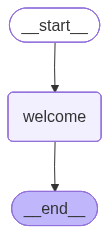

In [13]:
from typing import TypedDict
from langgraph.graph import StateGraph , START,END

class sample_schema(TypedDict):
    name:str
    message:str

def welcome(input:sample_schema)->sample_schema:
    name=input['name']
    message=input['message']
    response=llm.invoke(f"hi this is {name} , please explain about {message} .").content
    input['message']=response
    return input


graph=StateGraph(sample_schema)



graph.add_node("welcome",welcome)

graph.add_edge(START,"welcome")
graph.add_edge("welcome",END)

graph.compile()    




In [16]:

data={"name":"uthej","message":"I want you to create test cases for basic source file vs targe table ETL validation\n I want you to create in comma delimited with fields testcaseid , testcasedescription , expected results"}
graph.compile().invoke(data)

{'name': 'uthej',
 'message': 'Absolutely — below is a **comma-delimited test case list** for **basic source file vs target table ETL validation** with the fields:\n\n**testcaseid, testcasedescription, expected results**\n\n```csv\ntestcaseid,testcasedescription,expected results\nTC001,Validate source file record count matches target table record count,Source file record count should match target table record count\nTC002,Validate all source columns are loaded into the target table correctly,All mapped columns should match between source file and target table\nTC003,Validate data type conversion for numeric fields,Numeric values should be loaded correctly into target table without conversion errors\nTC004,Validate data type conversion for date fields,Date values should be loaded in the expected target format\nTC005,Validate blank or null values in source file are handled correctly,Blank or null values should be loaded according to ETL rules without errors\nTC006,Validate duplicate reco

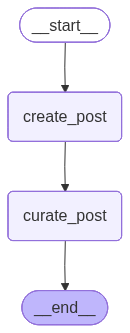

In [20]:
class post_schema(TypedDict):
    topic:str
    post:str
    curated_post:str


def create_post(state:post_schema)->post_schema:
    topic=state['topic']
    response=llm.invoke(f"please give in information about topic {topic}").content
    state['post']=response
    return state

def curate_post(state:post_schema)->post_schema:
    post=state['post']
    response=llm.invoke(f"please curate the below post for linkedin \n '{post}'").content
    state['curated_post']=response
    return state

post_graph=StateGraph(post_schema)
post_graph.add_node("create_post",create_post)
post_graph.add_node("curate_post",curate_post)

post_graph.add_edge(START,"create_post")
post_graph.add_edge("create_post","curate_post")
post_graph.add_edge("curate_post",END)

post_graph.compile()




In [21]:
first_graph=post_graph.compile()
first_graph.invoke({"topic":"sexual desires"})

{'topic': 'sexual desires',
 'post': 'Sexual desire is the feeling of wanting sexual activity or sexual intimacy. It’s a normal part of human life, and the level of desire can vary a lot from person to person and across different times in a person’s life.\n\n### Main things to know\n- **It’s influenced by many factors:** hormones, stress, sleep, mood, relationship quality, medications, health conditions, and past experiences.\n- **It changes over time:** desire may be stronger in some periods and lower in others.\n- **There’s no single “normal”:** some people feel sexual desire often, some rarely, and some not at all.\n- **It can be affected by emotions:** feeling safe, respected, and emotionally connected can increase desire for many people.\n\n### Common factors that affect sexual desire\n- **Physical health:** illness, pain, fatigue, hormonal changes\n- **Mental health:** anxiety, depression, stress, low self-esteem\n- **Medication:** some antidepressants and other drugs can lower d